In [1]:
import pandas as pd
df = pd.read_csv('time_series_health_data.csv')
df

,timestamp,patient_id,temperature,heart_rate,blood_oxygen,status
0,1500,V21,35.600002,54.0,100.0,healthy
1,1530,V21,35.700001,54.0,100.0,healthy
2,1560,V21,35.799999,55.0,100.0,healthy
3,1590,V21,35.799999,54.0,100.0,healthy
4,1620,V21,35.900002,54.0,100.0,healthy
...,...,...,...,...,...,...
83341,17910,V6386,35.500000,65.0,100.0,healthy
83342,17940,V6386,35.500000,65.0,100.0,healthy
83343,17970,V6386,35.500000,64.0,100.0,healthy
83344,18000,V6386,35.500000,64.0,100.0,healthy



===== DATA OVERVIEW =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83346 entries, 0 to 83345
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     83346 non-null  datetime64[ns]
 1   patient_id    83346 non-null  object        
 2   temperature   83346 non-null  float64       
 3   heart_rate    83346 non-null  float64       
 4   blood_oxygen  83346 non-null  float64       
 5   status        83346 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(3), object(1)
memory usage: 3.3+ MB
None

===== FIRST ROWS =====
   timestamp patient_id  temperature  heart_rate  blood_oxygen   status
0 1970-01-01       V187    36.588832        64.6          97.0    risky
1 1970-01-01       V876    36.603615       108.1          99.0    risky
2 1970-01-01      V5611    36.727574        90.0          97.0  healthy
3 1970-01-01      V4908    36.583855        64.6          98.0  

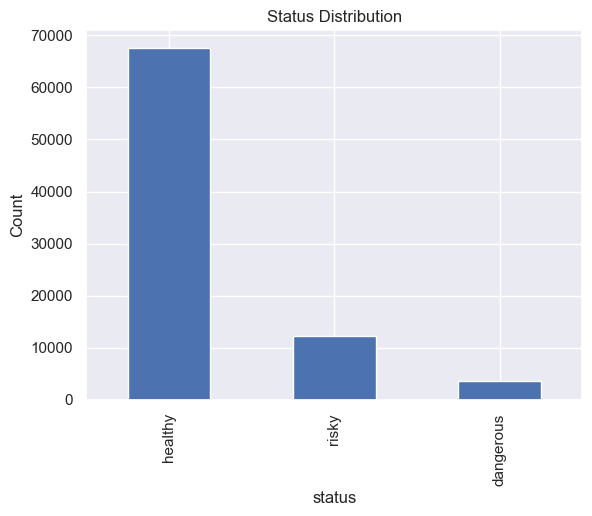


===== OUTLIER COUNT (Z > 3) =====
temperature     1242
heart_rate       386
blood_oxygen    1219
dtype: int64


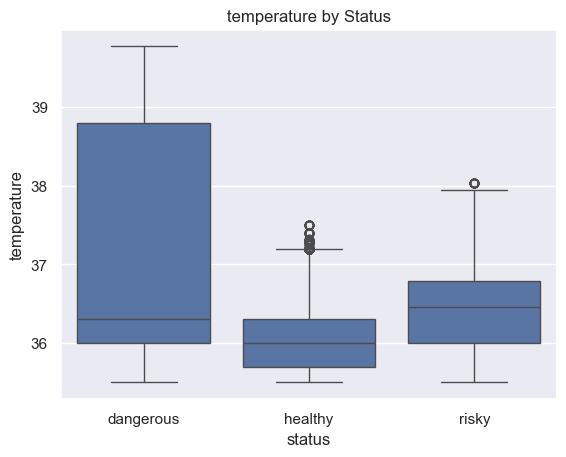

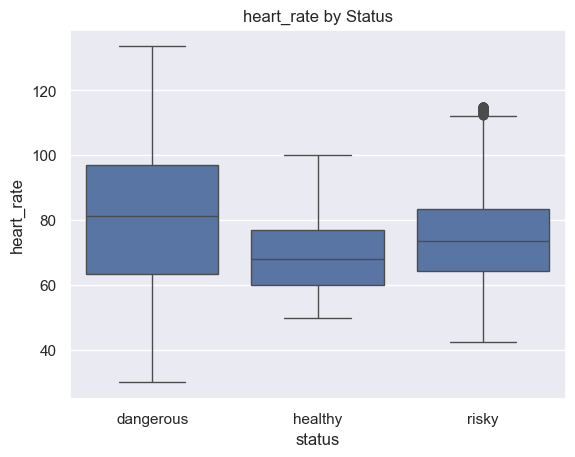

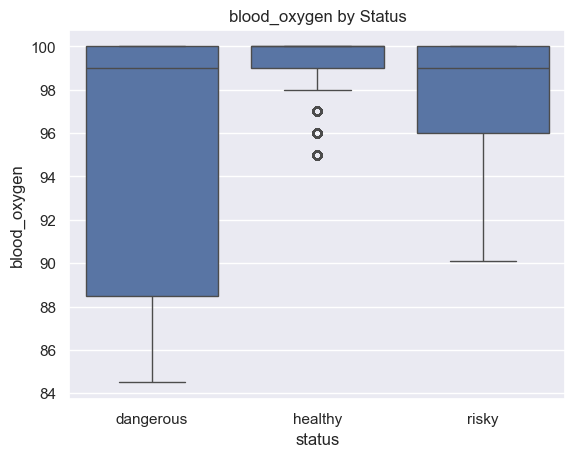


===== FINAL SUMMARY =====
Total Records: 83346
Patients: 380
Time Range: 1970-01-01 00:00:00 to 1970-01-01 06:34:30


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme()

# Ensure correct datatypes
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
df['patient_id'] = df['patient_id'].astype(str)
df['status'] = df['status'].astype('category')

# Sort 
df = df.sort_values("timestamp").reset_index(drop=True)

print("\n===== DATA OVERVIEW =====")
print(df.info())

print("\n===== FIRST ROWS =====")
print(df.head())

print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== STATUS DISTRIBUTION =====")
print(df['status'].value_counts())

plt.figure()
df['status'].value_counts().plot(kind='bar')
plt.title("Status Distribution")
plt.ylabel("Count")
plt.show()

numeric_cols = ['temperature', 'heart_rate', 'blood_oxygen']

# ===============================
# 9. Outlier Detection (Z-score)
# ===============================
from scipy.stats import zscore

z_scores = np.abs(zscore(df[numeric_cols]))
outliers = (z_scores > 3)

outlier_counts = pd.DataFrame(outliers, columns=numeric_cols).sum()
print("\n===== OUTLIER COUNT (Z > 3) =====")
print(outlier_counts)

# ===============================
# 10. Relationship with Status
# ===============================
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x='status', y=col, data=df)
    plt.title(f"{col} by Status")
    plt.show()

print("\n===== FINAL SUMMARY =====")
print(f"Total Records: {len(df)}")
print(f"Patients: {df['patient_id'].nunique()}")
print(f"Time Range: {df['timestamp'].min()} to {df['timestamp'].max()}")


Healthy records: 67593
        temperature    heart_rate  blood_oxygen
count  67593.000000  67593.000000  67593.000000
mean      36.073699     69.006273     99.479665
std        0.406564     11.354892      0.937526
min       35.500000     50.000000     95.000000
25%       35.700001     60.000000     99.000000
50%       36.000000     68.000000    100.000000
75%       36.299999     77.000000    100.000000
max       37.500000    100.000000    100.000000

Correlation (healthy):
              temperature  heart_rate  blood_oxygen
temperature      1.000000    0.059194     -0.004317
heart_rate       0.059194    1.000000      0.032771
blood_oxygen    -0.004317    0.032771      1.000000


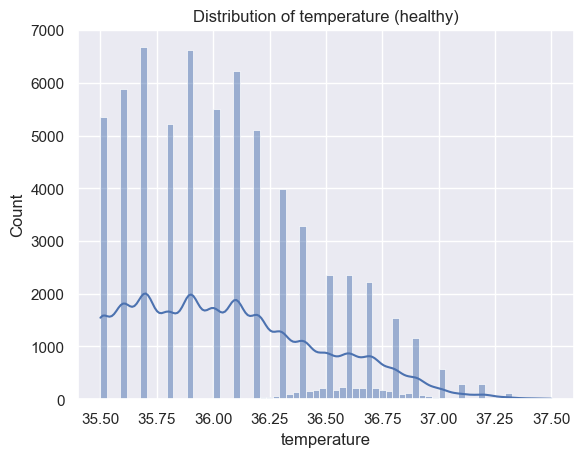

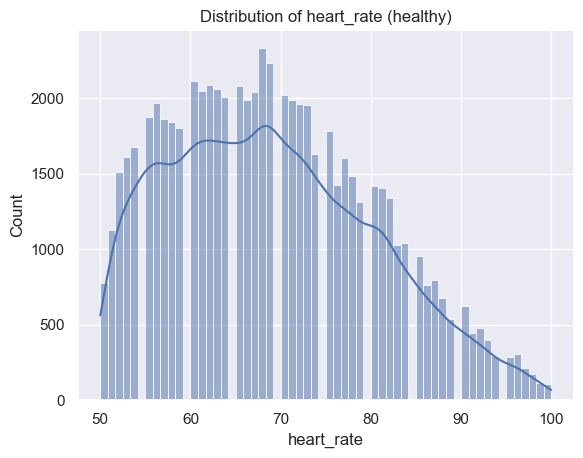

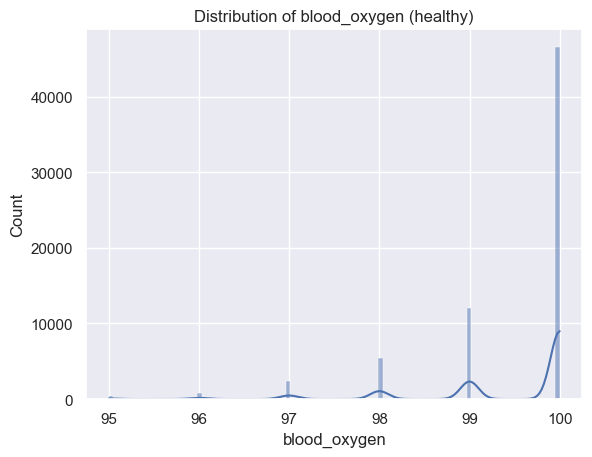

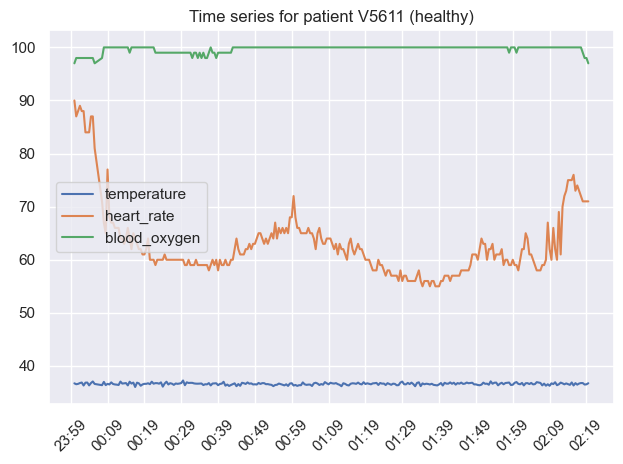

In [ ]:
import matplotlib.dates as mdates

healthy = df[df['status'] == 'healthy']

print(f"Healthy records: {len(healthy)}")
print(healthy[numeric_cols].describe())

print("\nCorrelation (healthy):")
print(healthy[numeric_cols].corr())

for col in numeric_cols:
    plt.figure()
    sns.histplot(healthy[col], kde=True)
    plt.title(f"Distribution of {col} (healthy)")
    plt.xlabel(col)
    plt.show()

# example time series for a single healthy patient
sample_id = healthy['patient_id'].iloc[0]
sample = healthy[healthy['patient_id'] == sample_id]

plt.figure()
for col in numeric_cols:
    plt.plot(sample['timestamp'], sample[col], label=col)
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
plt.title(f"Time series for patient {sample_id} (healthy)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()